In [2]:
!pip install pandas matplotlib seaborn numpy

     ---------------------------------------- 7.2/7.2 MB 2.6 MB/s eta 0:00:00
     -------------------------------------- 293.3/293.3 kB 1.6 MB/s eta 0:00:00
     ---------------------------------------- 2.5/2.5 MB 1.6 MB/s eta 0:00:00
     -------------------------------------- 104.1/104.1 kB 3.0 MB/s eta 0:00:00
     ---------------------------------------- 55.8/55.8 kB 1.4 MB/s eta 0:00:00
     -------------------------------------- 965.4/965.4 kB 2.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df = pd.read_csv("kaggle data/train.csv")

In [9]:
df.head()

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,Yes,No,Airways,No,Working Class,No,06/07/15,06/03/15,"New Michelle, OH 50777",-283.29
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,No,No,Roadways,No,Working Class,No,03/06/17,03/05/17,"New Michaelport, WY 12072",-159.96
2,fffe3600370035003100,Laura Miller,0.07,8.0,5.0,237.0,Clay,4.96,21.18,No,No,No,Roadways,Yes,Working Class,Yes,03/09/15,03/08/15,"Bowmanshire, WA 19241",-154.29
3,fffe350031003300,Robert Chaires,0.12,9.0,NaN,NaN,Aluminium,5.81,16.31,No,No,No,NaN,No,Wealthy,Yes,05/24/15,05/20/15,"East Robyn, KY 86375",-161.16
4,fffe3900320038003400,Rosalyn Krol,0.15,17.0,6.0,324.0,Aluminium,3.18,11.94,Yes,Yes,Yes,Airways,No,Working Class,No,12/18/16,12/14/16,"Aprilside, PA 52793",-159.23


In [11]:
df.shape

(6500, 20)

In [12]:
df.describe()

,Artist Reputation,Height,Width,Weight,Price Of Sculpture,Base Shipping Price,Cost
count,5750.000000,6125.000000,5916.000000,5.913000e+03,6500.00000,6500.000000,6.500000e+03
mean,0.461850,21.766204,9.617647,4.006948e+05,1192.42009,37.407174,1.713920e+04
std,0.265781,11.968192,5.417000,2.678081e+06,8819.61675,26.873519,2.406579e+05
min,0.000000,3.000000,2.000000,3.000000e+00,3.00000,10.000000,-8.801727e+05
25%,0.240000,12.000000,6.000000,5.030000e+02,5.23000,16.700000,1.884400e+02
50%,0.450000,20.000000,8.000000,3.102000e+03,8.02500,23.505000,3.820650e+02
75%,0.680000,30.000000,12.000000,3.645600e+04,89.47000,57.905000,1.156115e+03
max,1.000000,73.000000,50.000000,1.179279e+08,382385.67000,99.980000,1.114343e+07


In [13]:
df.dtypes

Customer Id               object
Artist Name               object
Artist Reputation        float64
Height                   float64
Width                    float64
Weight                   float64
Material                  object
Price Of Sculpture       float64
Base Shipping Price      float64
International             object
Express Shipment          object
Installation Included     object
Transport                 object
Fragile                   object
Customer Information      object
Remote Location           object
Scheduled Date            object
Delivery Date             object
Customer Location         object
Cost                     float64
dtype: object

In [16]:
target_feature = "Cost"

numeric_features = [feature for feature in df.columns if df[feature].dtype != "O"]

categorical_features = [feature for feature in df.columns if df[feature].dtype == "O"]

print(f'We have {len(numeric_features)} numerical features : {numeric_features}')
print(f'\nWe have {len(categorical_features)} categorical_features: {categorical_features}')

We have 7 numerical features : ['Artist Reputation', 'Height', 'Width', 'Weight', 'Price Of Sculpture', 'Base Shipping Price', 'Cost']

We have 13 categorical_features: ['Customer Id', 'Artist Name', 'Material', 'International', 'Express Shipment', 'Installation Included', 'Transport', 'Fragile', 'Customer Information', 'Remote Location', 'Scheduled Date', 'Delivery Date', 'Customer Location']


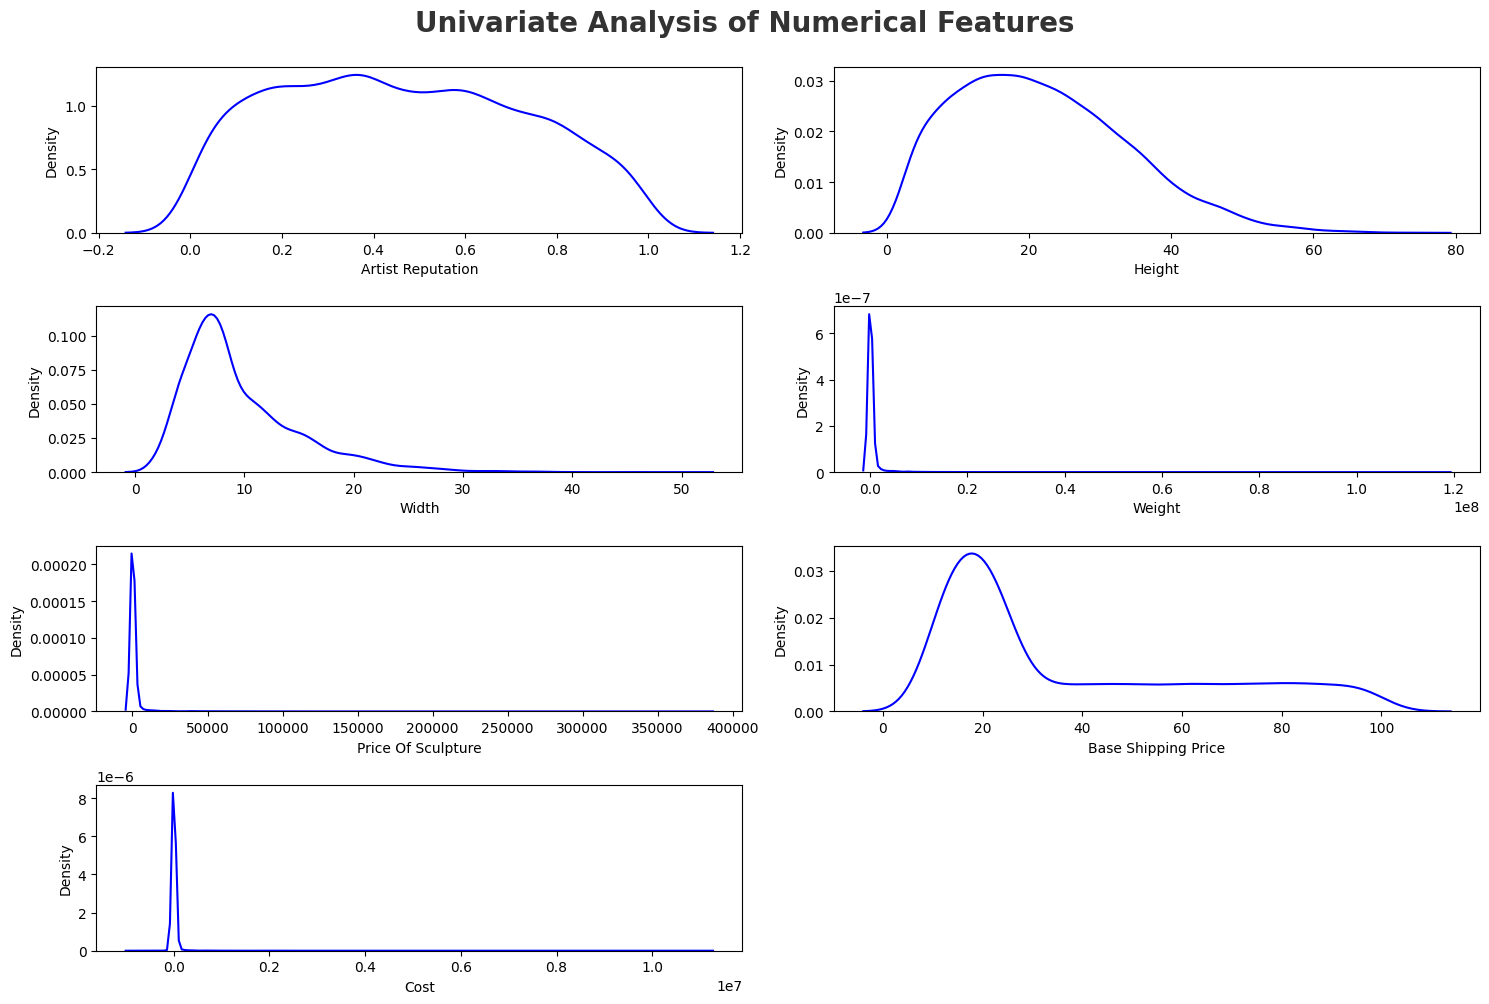

In [18]:
# Plotting histograms for each numerical feature
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(4, 2, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

In [19]:
df.describe()

,Artist Reputation,Height,Width,Weight,Price Of Sculpture,Base Shipping Price,Cost
count,5750.000000,6125.000000,5916.000000,5.913000e+03,6500.00000,6500.000000,6.500000e+03
mean,0.461850,21.766204,9.617647,4.006948e+05,1192.42009,37.407174,1.713920e+04
std,0.265781,11.968192,5.417000,2.678081e+06,8819.61675,26.873519,2.406579e+05
min,0.000000,3.000000,2.000000,3.000000e+00,3.00000,10.000000,-8.801727e+05
25%,0.240000,12.000000,6.000000,5.030000e+02,5.23000,16.700000,1.884400e+02
50%,0.450000,20.000000,8.000000,3.102000e+03,8.02500,23.505000,3.820650e+02
75%,0.680000,30.000000,12.000000,3.645600e+04,89.47000,57.905000,1.156115e+03
max,1.000000,73.000000,50.000000,1.179279e+08,382385.67000,99.980000,1.114343e+07


In [24]:
#for catogerial columns
categorical_columns = []
for i in categorical_features:
    print(f"{i}: {len(df[i].unique())}")
    if len(df[i].unique())<10:
        categorical_columns.append(i)

Customer Id: 6500
Artist Name: 6449
Material: 8
International: 2
Express Shipment: 2
Installation Included: 2
Transport: 4
Fragile: 2
Customer Information: 2
Remote Location: 3
Scheduled Date: 1660
Delivery Date: 1664
Customer Location: 6500


In [25]:
categorical_columns

['Material',
 'International',
 'Express Shipment',
 'Installation Included',
 'Transport',
 'Fragile',
 'Customer Information',
 'Remote Location']

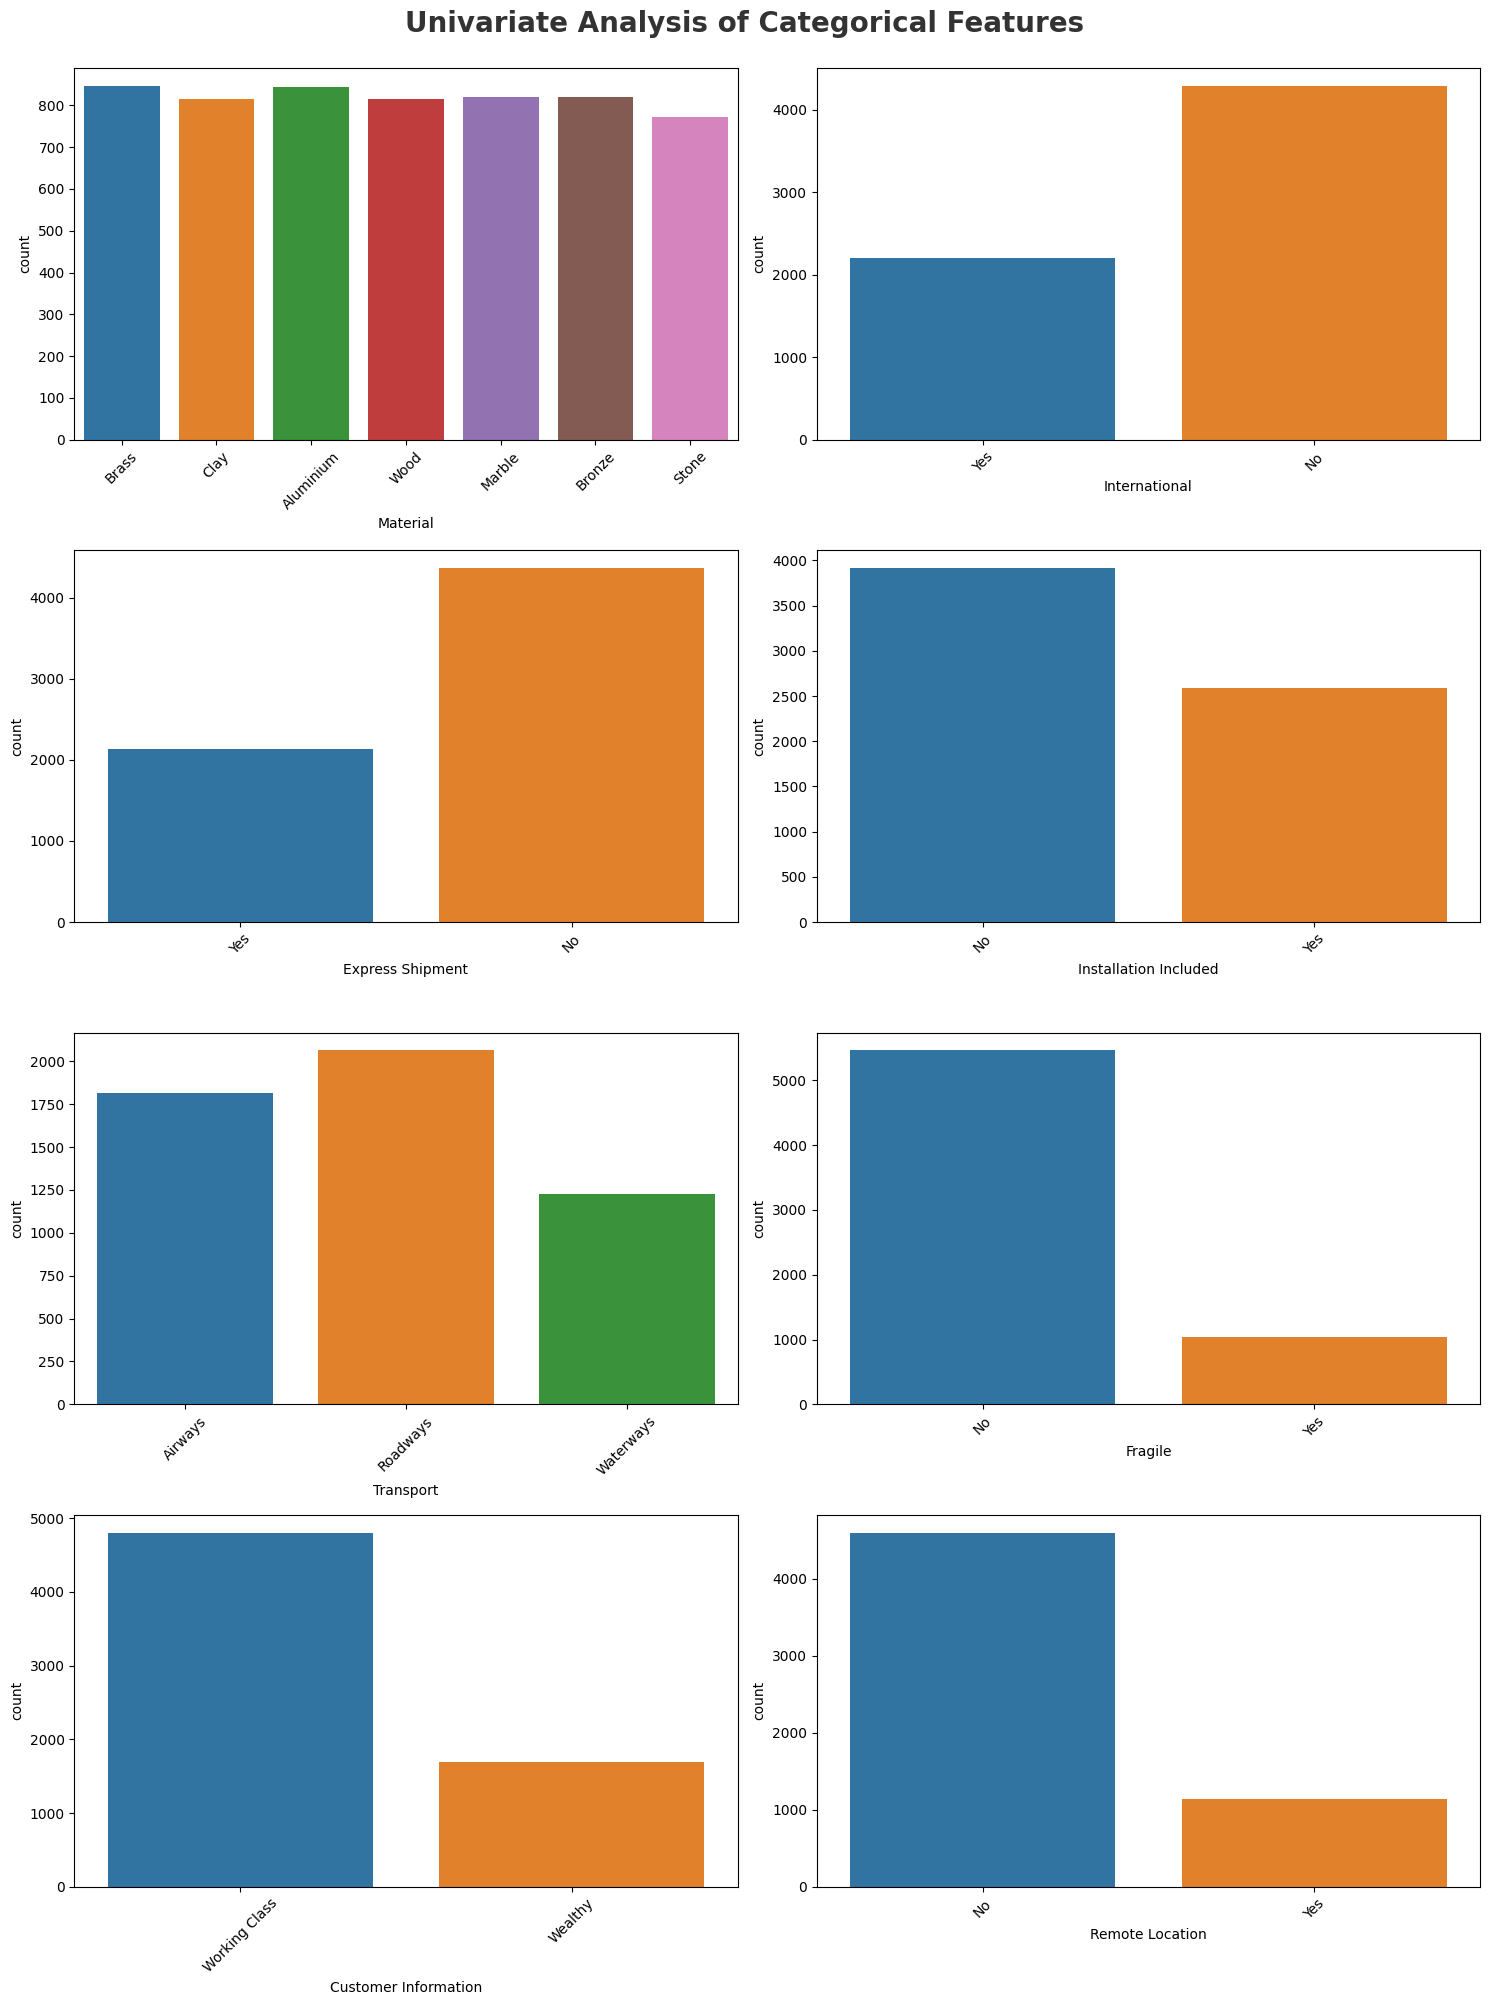

In [26]:
# categorical columns
plt.figure(figsize=(15, 20))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
for i in range(0, len(categorical_columns)):
    plt.subplot(4, 2, i+1)
    sns.countplot(x=df[categorical_columns[i]])
    plt.xlabel(categorical_columns[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

In [27]:
df.isnull().sum()

Customer Id                 0
Artist Name                 0
Artist Reputation         750
Height                    375
Width                     584
Weight                    587
Material                  764
Price Of Sculpture          0
Base Shipping Price         0
International               0
Express Shipment            0
Installation Included       0
Transport                1392
Fragile                     0
Customer Information        0
Remote Location           771
Scheduled Date              0
Delivery Date               0
Customer Location           0
Cost                        0
dtype: int64

In [30]:
df[list((df.columns)[1:])].corr()

,Artist Reputation,Height,Width,Weight,Price Of Sculpture,Base Shipping Price,Cost
Artist Reputation,1.000000,-0.000513,-0.009203,0.017113,0.054286,-0.011820,0.067368
Height,-0.000513,1.000000,0.768376,0.226543,0.200942,0.353858,0.106047
Width,-0.009203,0.768376,1.000000,0.329603,0.293544,0.332361,0.158159
Weight,0.017113,0.226543,0.329603,1.000000,0.890205,0.150856,0.417263
Price Of Sculpture,0.054286,0.200942,0.293544,0.890205,1.000000,0.134407,0.476231
Base Shipping Price,-0.011820,0.353858,0.332361,0.150856,0.134407,1.000000,0.053068
Cost,0.067368,0.106047,0.158159,0.417263,0.476231,0.053068,1.000000


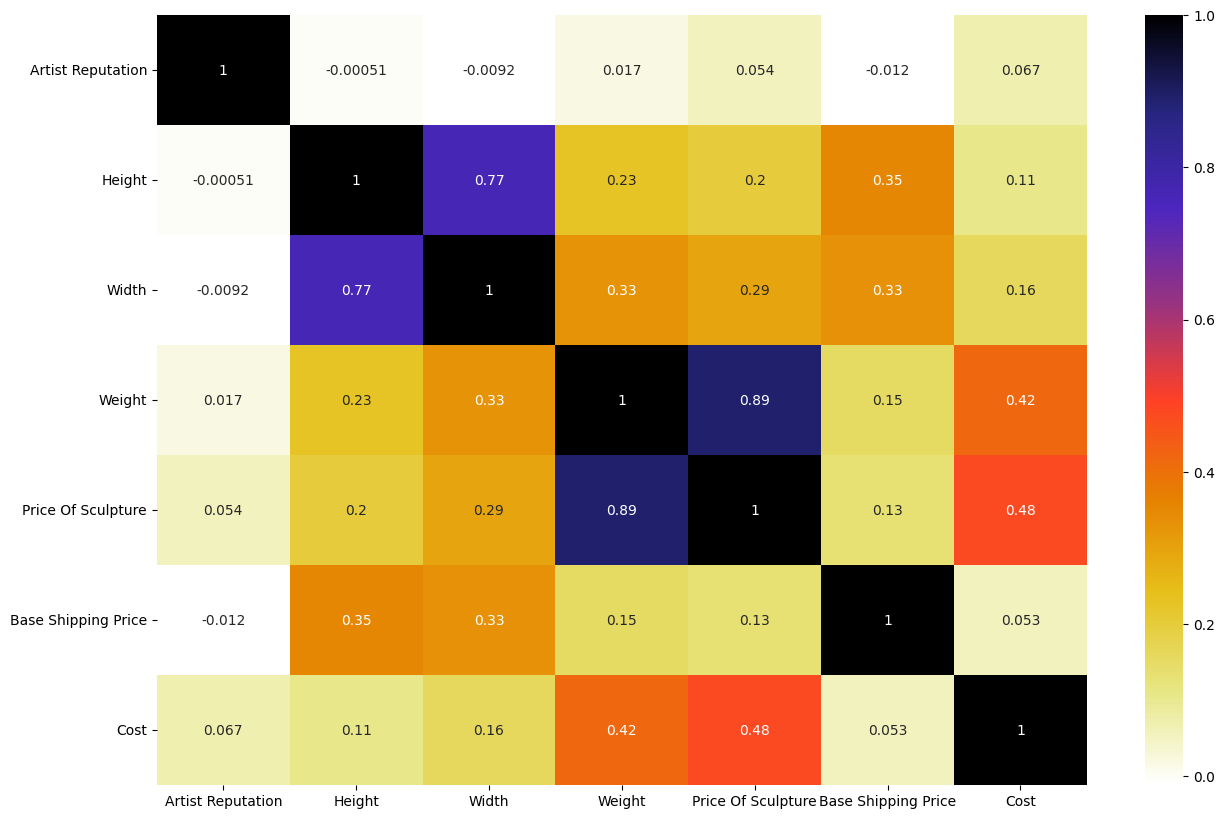

In [32]:
plt.figure(figsize = (15,10))
sns.heatmap(df.corr() , cmap="CMRmap_r" , annot = True)
plt.show()


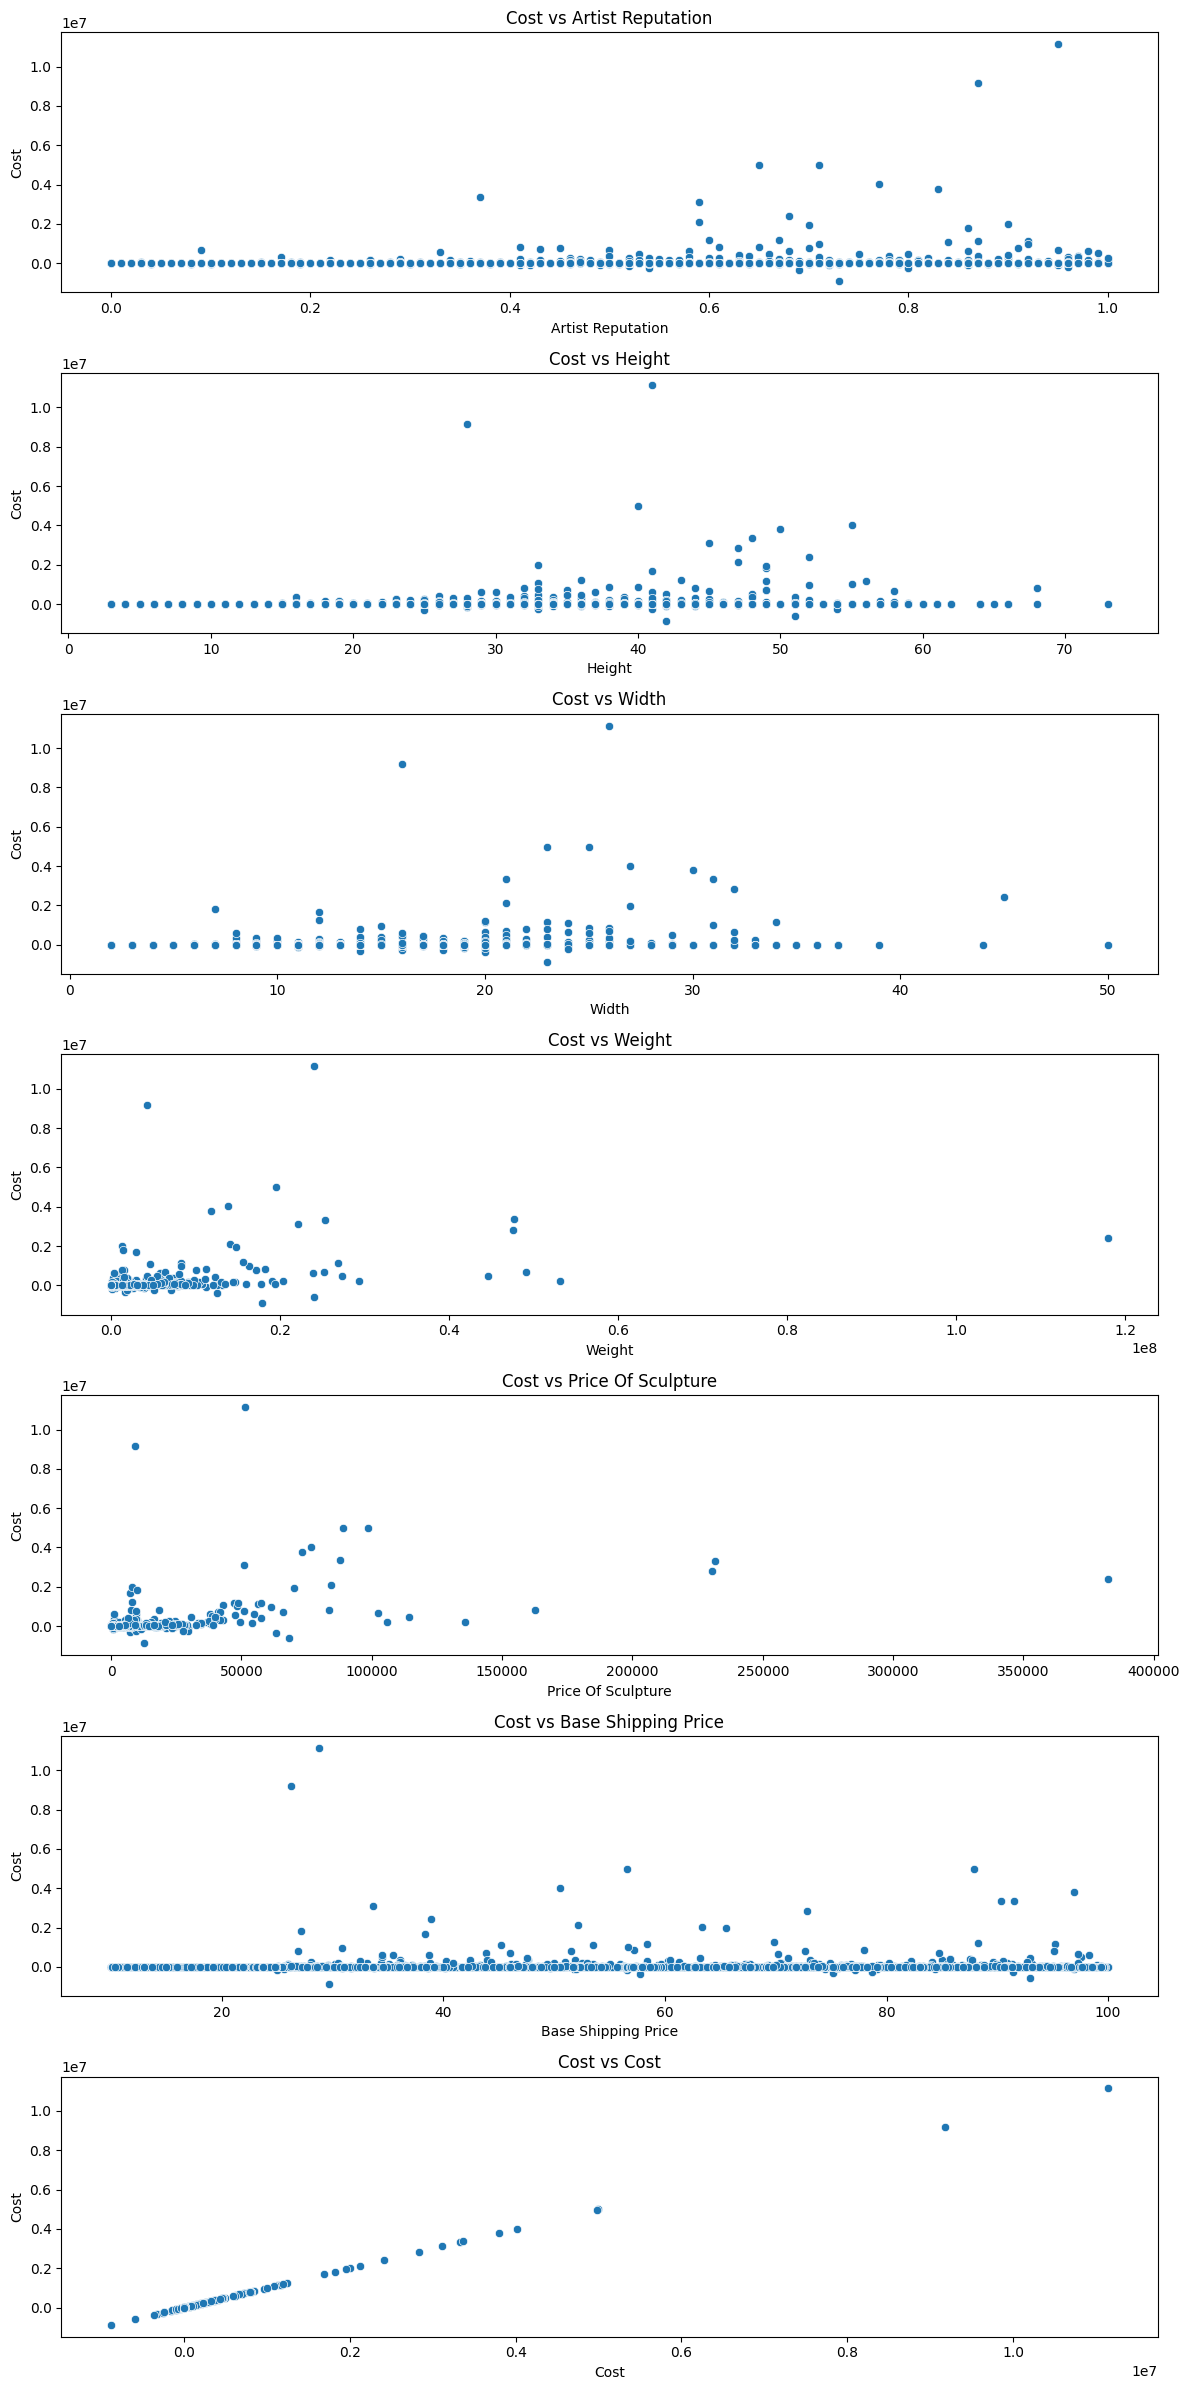

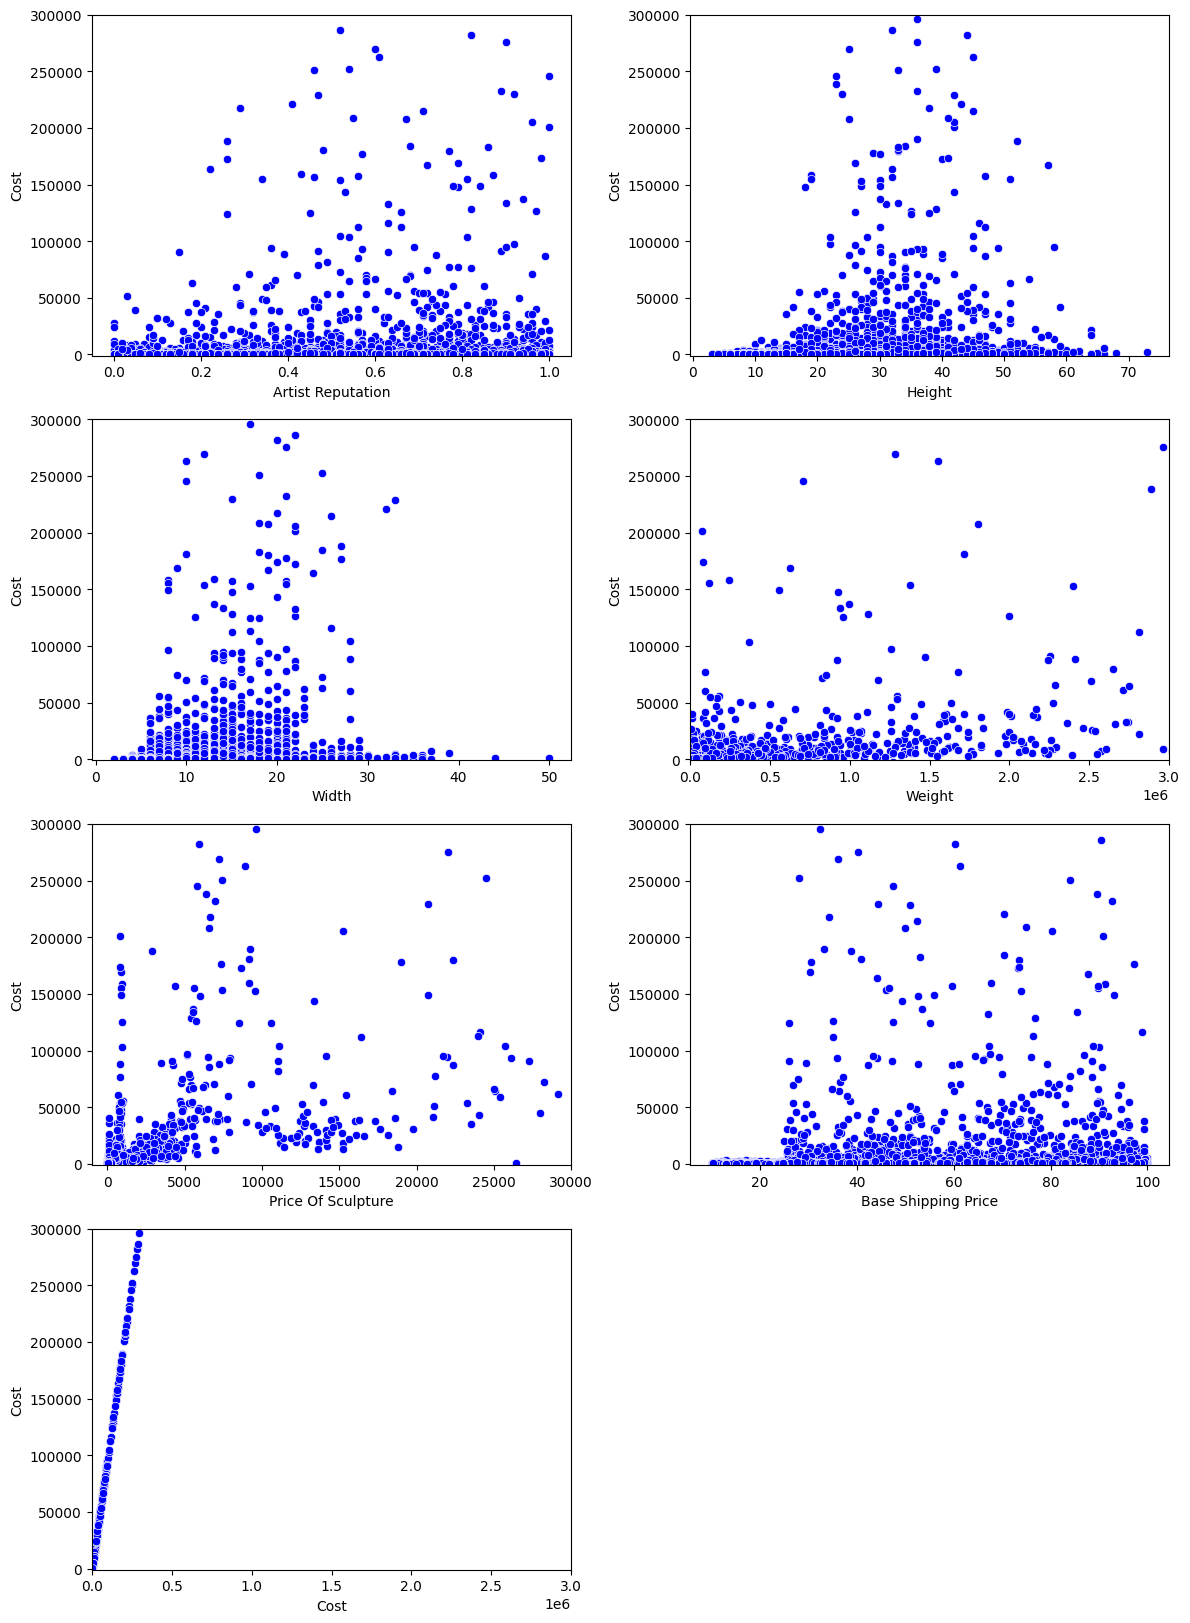

In [34]:
fig = plt.figure(figsize=(12, 24))

for i in range(0, len(numeric_features)):
    ax = plt.subplot(6, 2, i+1)
    sns.scatterplot(data= df ,y=target_feature, x=numeric_features[i], color='b')
    if df[numeric_features[i]].max() > 30000:
        plt.xlim(-1000,30000)   
    if df[numeric_features[i]].max() > 3000000:
        plt.xlim(-1000,3000000)
    plt.ylim(-1000, 300000)
    plt.tight_layout()

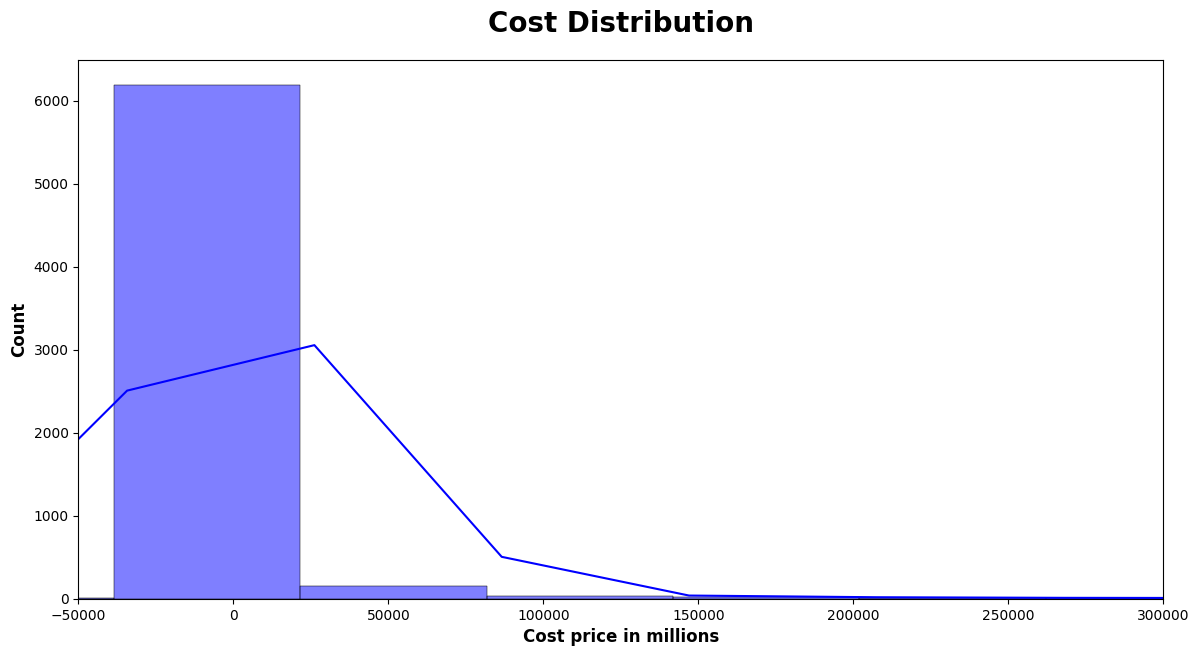

In [35]:
plt.subplots(figsize=(14,7))
sns.histplot(df[target_feature], bins=200, kde=True, color = 'b')
plt.title("Cost Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Cost price in millions", weight="bold", fontsize=12)
plt.xlim(-50000,300000)
plt.show()

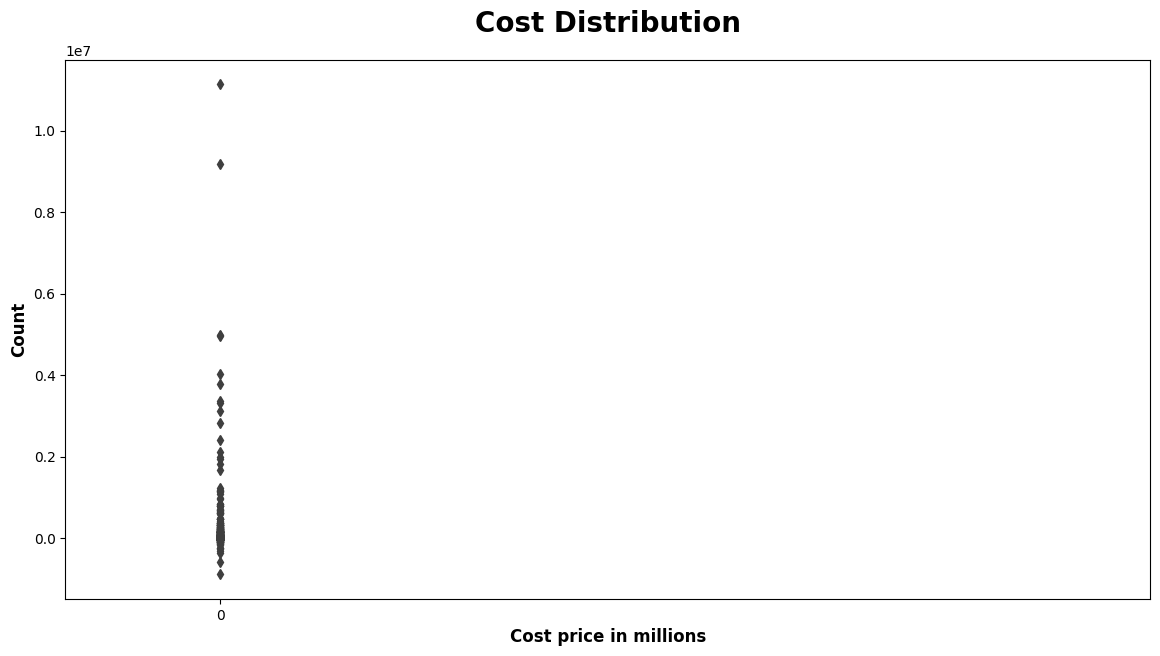

In [37]:
plt.subplots(figsize=(14,7))
sns.boxplot(df[target_feature])
plt.title("Cost Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Cost price in millions", weight="bold", fontsize=12)
plt.xlim(-50000,300000);

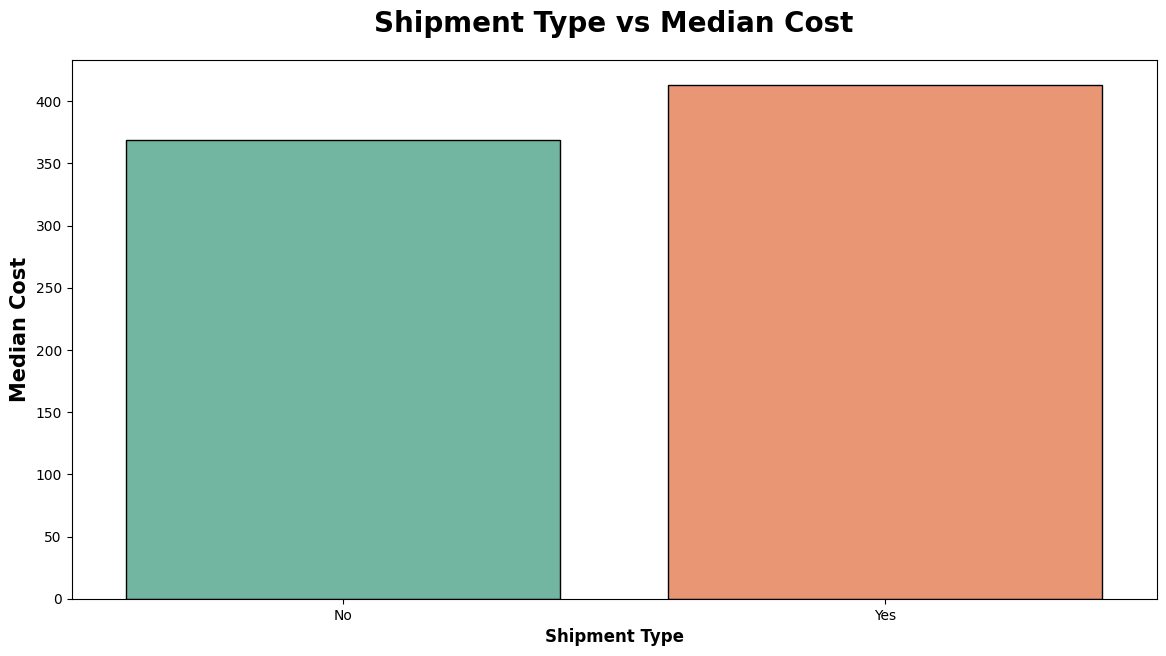

In [40]:
#how shipment is affecting cost of shipment???

international = df.groupby("International")[target_feature].median()
international.to_frame()

plt.subplots(figsize=(14,7))
sns.barplot(x=international.index, y=international.values, ec = "black", palette="Set2")
plt.title("Shipment Type vs Median Cost", weight="bold",fontsize=20, pad=20)
plt.ylabel("Median Cost", weight="bold", fontsize=15)
plt.xlabel("Shipment Type", weight="bold", fontsize=12)
plt.show()



In [42]:
df["International"].value_counts()

No     4294
Yes    2206
Name: International, dtype: int64

In [44]:
international_shipment_median = df[df["International"] == "Yes"]["Cost"].median()

domestic_shipment_median = df[df["International"] == "No"]["Cost"].median()

print(f" The difference between the median price of International shipment and Domestic shipment is: {international_shipment_median - domestic_shipment_median}")



 The difference between the median price of International shipment and Domestic shipment is: 43.91500000000008


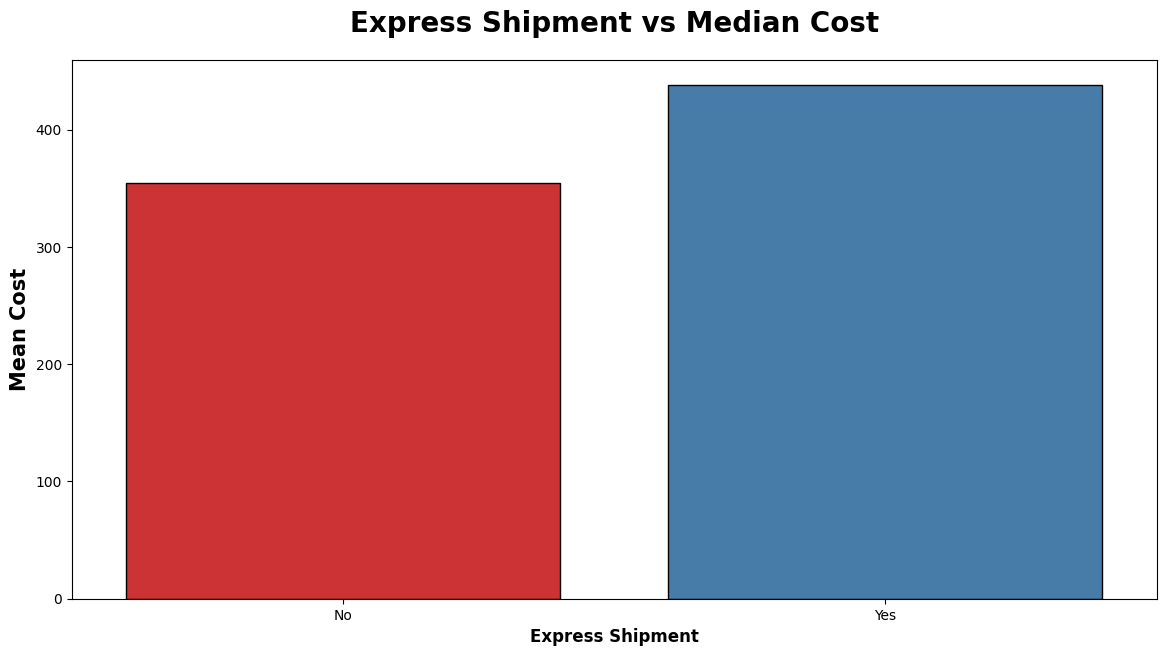

In [47]:
#how expresss shipment is affefcting the cost of shipment

express_ship = df.groupby("Express Shipment")[target_feature].median()
express_ship.to_frame()

plt.subplots(figsize=(14,7))
sns.barplot(x=express_ship.index, y=express_ship.values, ec = "black", palette="Set1")
plt.title("Express Shipment vs Median Cost", weight="bold",fontsize=20, pad=20)
plt.ylabel("Mean Cost", weight="bold", fontsize=15)
plt.xlabel("Express Shipment", weight="bold", fontsize=12)
plt.show()

In [49]:
df["Express Shipment"].value_counts()

No     4365
Yes    2135
Name: Express Shipment, dtype: int64

In [50]:
express_shipment_median =  df[df["Express Shipment"] == "Yes"]["Cost"].median()
normal_shipment_median =  df[df["Express Shipment"] == "No"]["Cost"].median()

print(f"The difference between express shipment and normal shipment cost is: {express_shipment_median - normal_shipment_median}")

The difference between express shipment and normal shipment cost is: 83.08000000000004


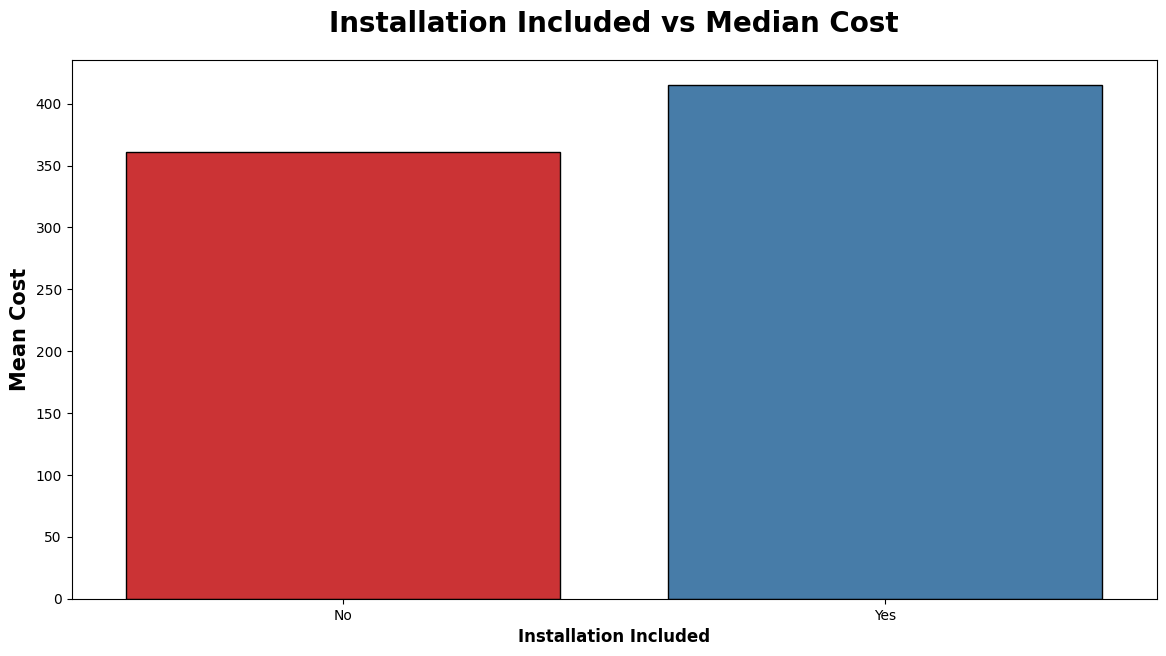

In [53]:
#installation affecting shipment or not 

installation = df.groupby("Installation Included")["Cost"].median()
installation.to_frame()

plt.subplots(figsize=(14,7))
sns.barplot(x=installation.index, y=installation.values, ec = "black", palette="Set1")
plt.title("Installation Included vs Median Cost", weight="bold",fontsize=20, pad=20)
plt.ylabel("Mean Cost", weight="bold", fontsize=15)
plt.xlabel("Installation Included", weight="bold", fontsize=12)
plt.show()


In [54]:
df['Installation Included'].value_counts()

No     3916
Yes    2584
Name: Installation Included, dtype: int64

In [55]:
installation_needed_median = df[df["Installation Included"] == "Yes"]["Cost"].median()
installation_not_needed_median = df[df["Installation Included"] == "No"]["Cost"].median()

print(f"The difference between the median shipment price of Installation Included and not is {installation_needed_median-installation_not_needed_median}")

The difference between the median shipment price of Installation Included and not is 53.67500000000001


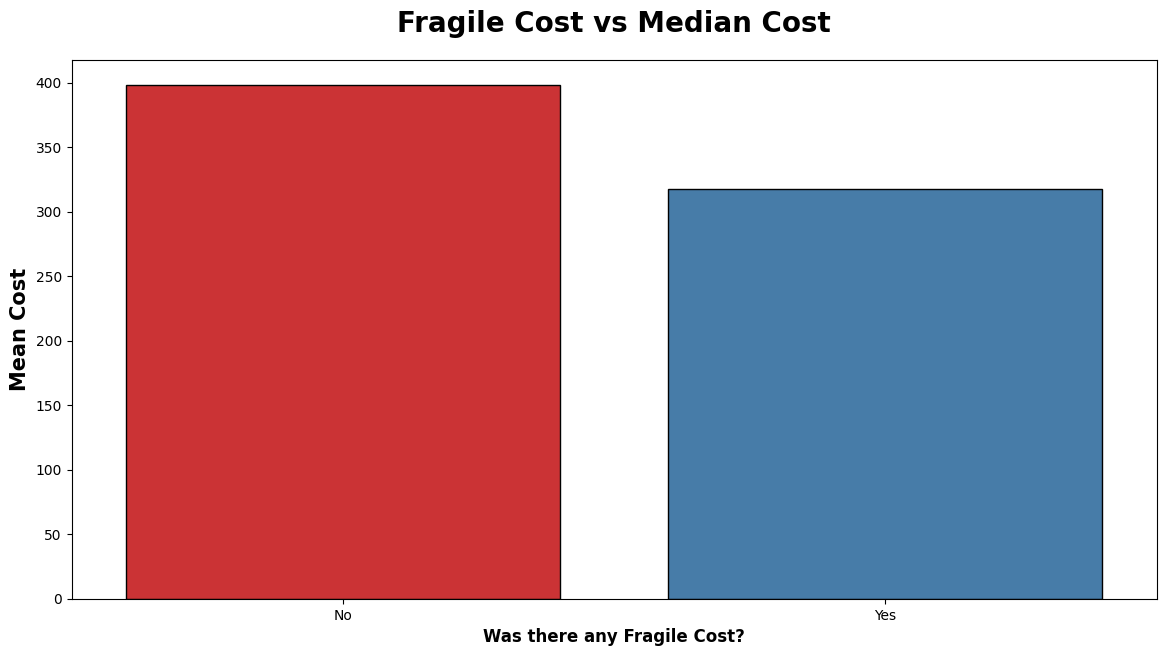

In [57]:
#how fragile is effecting the cost

fragile = df.groupby('Fragile')[target_feature].median()
fragile.to_frame()

plt.subplots(figsize=(14,7))
sns.barplot(x=fragile.index, y=fragile.values, ec = "black", palette="Set1")
plt.title("Fragile Cost vs Median Cost", weight="bold",fontsize=20, pad=20)
plt.ylabel("Mean Cost", weight="bold", fontsize=15)
plt.xlabel("Was there any Fragile Cost?", weight="bold", fontsize=12)
plt.show()

In [62]:
df["Fragile"].value_counts()

No     5461
Yes    1039
Name: Fragile, dtype: int64

In [63]:
fragile_median = df[df['Fragile'] == 'Yes']['Cost'].median()
fragile_not_median = df[df['Fragile'] == 'No']['Cost'].median()

print(f"The difference between the median shipment price of Fragile cost and non-fragile cost is {fragile_median-fragile_not_median}")

The difference between the median shipment price of Fragile cost and non-fragile cost is -80.03000000000003


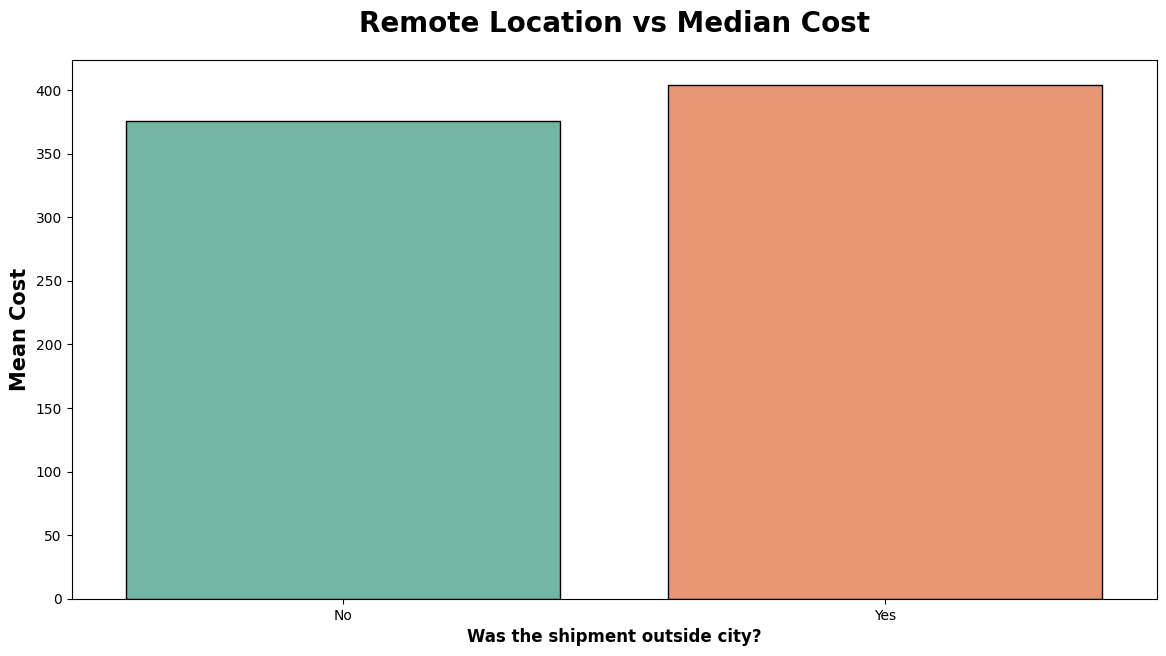

In [64]:
#How delivery location is affecting cost of shipment?

remote = df.groupby('Remote Location')[target_feature].median()
remote.to_frame()

plt.subplots(figsize=(14,7))
sns.barplot(x=remote.index, y=remote.values, ec = "black", palette="Set2")
plt.title("Remote Location vs Median Cost", weight="bold",fontsize=20, pad=20)
plt.ylabel("Mean Cost", weight="bold", fontsize=15)
plt.xlabel("Was the shipment outside city?", weight="bold", fontsize=12)
plt.show()

In [65]:
df["Remote Location"].value_counts()

No     4594
Yes    1135
Name: Remote Location, dtype: int64

In [66]:
remote_median = df[df['Remote Location'] == 'Yes']['Cost'].median()
not_remote_median = df[df['Remote Location'] == 'No']['Cost'].median()

print(f"The difference between the median shipment price of remote shipment and non-remote shipment cost is {remote_median-not_remote_median}")

The difference between the median shipment price of remote shipment and non-remote shipment cost is 27.714999999999975


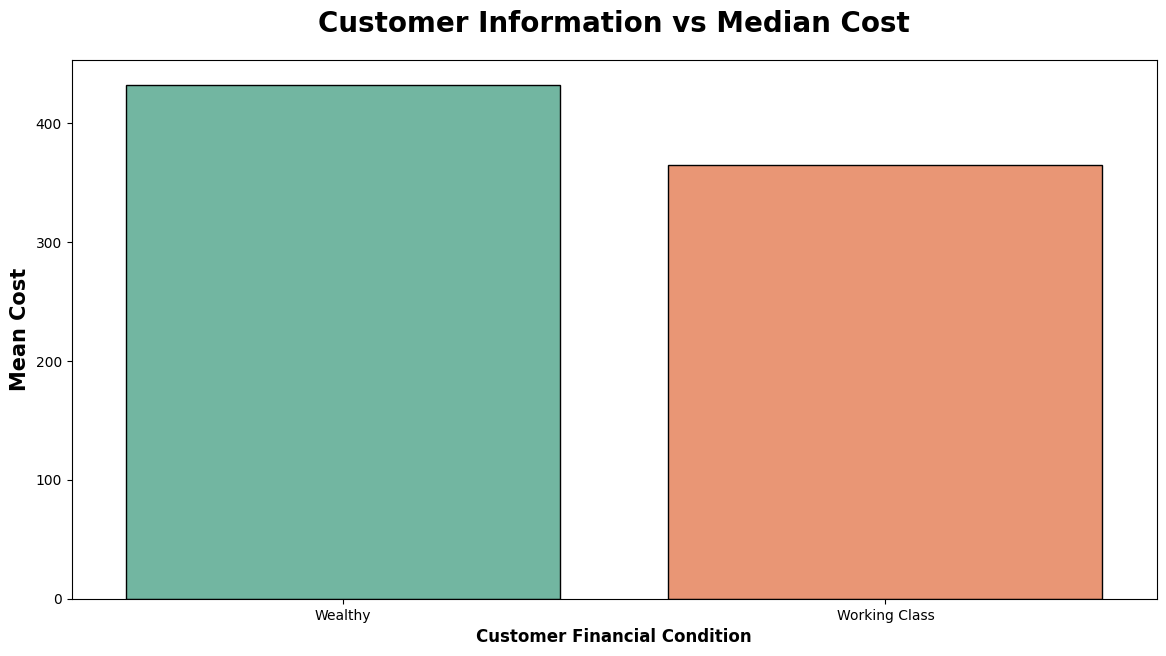

In [67]:
#How Customer Financial condition is affecting cost of shipment?

cust_info = df.groupby('Customer Information')[target_feature].median()
cust_info.to_frame()

plt.subplots(figsize=(14,7))
sns.barplot(x=cust_info.index, y=cust_info.values, ec = "black", palette="Set2")
plt.title("Customer Information vs Median Cost", weight="bold",fontsize=20, pad=20)
plt.ylabel("Mean Cost", weight="bold", fontsize=15)
plt.xlabel("Customer Financial Condition", weight="bold", fontsize=12)
plt.show()

In [69]:
df["Customer Information"].value_counts()

Working Class    4803
Wealthy          1697
Name: Customer Information, dtype: int64

In [71]:
customer_info_wealthy_median = df[df['Customer Information'] == 'Wealthy']['Cost'].median()
customer_info_working_class_median = df[df['Customer Information'] == 'Working Class']['Cost'].median()


print(f"The difference between the median shipment price of remote shipment and non-remote shipment cost is {customer_info_wealthy_median-customer_info_working_class_median}")

The difference between the median shipment price of remote shipment and non-remote shipment cost is 66.94


In [72]:
#for converting strings of year into python format

df["Scheduled Date"] = pd.to_datetime(df["Scheduled Date"])
df['Delivery Date'] = pd.to_datetime(df["Delivery Date"])

In [73]:
#Extracts just the year (2015, 2016, etc.) from each date and creates a new column called year similarly for month

df['year'] = pd.DatetimeIndex(df["Scheduled Date"]).year
df['month'] = pd.DatetimeIndex(df['Scheduled Date']).month

In [74]:
df.head()

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,...,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost,year,month
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,...,Airways,No,Working Class,No,2015-06-07,2015-06-03,"New Michelle, OH 50777",-283.29,2015,6
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,...,Roadways,No,Working Class,No,2017-03-06,2017-03-05,"New Michaelport, WY 12072",-159.96,2017,3
2,fffe3600370035003100,Laura Miller,0.07,8.0,5.0,237.0,Clay,4.96,21.18,No,...,Roadways,Yes,Working Class,Yes,2015-03-09,2015-03-08,"Bowmanshire, WA 19241",-154.29,2015,3
3,fffe350031003300,Robert Chaires,0.12,9.0,NaN,NaN,Aluminium,5.81,16.31,No,...,NaN,No,Wealthy,Yes,2015-05-24,2015-05-20,"East Robyn, KY 86375",-161.16,2015,5
4,fffe3900320038003400,Rosalyn Krol,0.15,17.0,6.0,324.0,Aluminium,3.18,11.94,Yes,...,Airways,No,Working Class,No,2016-12-18,2016-12-14,"Aprilside, PA 52793",-159.23,2016,12


In [78]:
#Group by Year and Month

x = df.groupby(["year","month"])["Cost"].mean()

df_wide = x.unstack().T 
df_wide.head()

year,2015,2016,2017,2018,2019
month,,,,,
1,1243.620800,12930.272703,13388.419779,47457.768519,2430.550495
2,34249.351818,10034.132545,3427.163673,6612.238687,3840.484630
3,23775.741185,10757.195810,41359.835804,20026.385455,2265.834019
4,94668.648276,4288.732696,26634.491452,4138.730309,8374.422975
5,15884.313833,4103.283514,8857.153077,17461.434118,14129.902741


In [79]:
df_wide[2015]

month
1      1243.620800
2     34249.351818
3     23775.741185
4     94668.648276
5     15884.313833
6      4480.208318
7      1426.520159
8     17085.121760
9      4258.188871
10     4979.386768
11    53043.073800
12    40081.836509
Name: 2015, dtype: float64

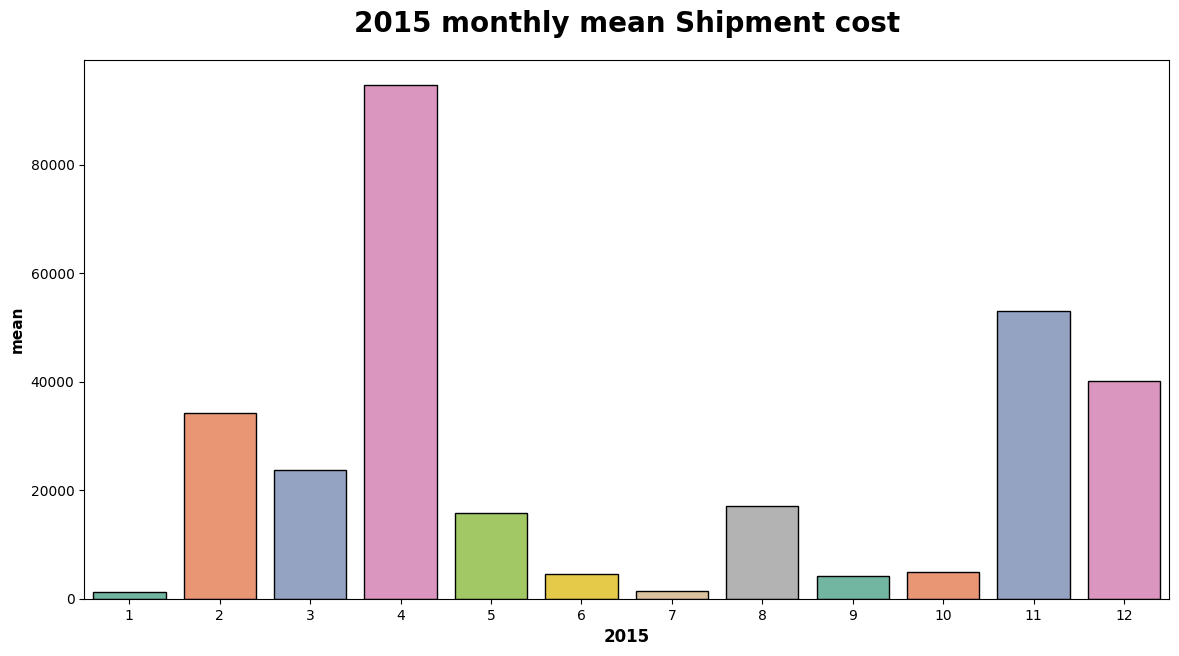

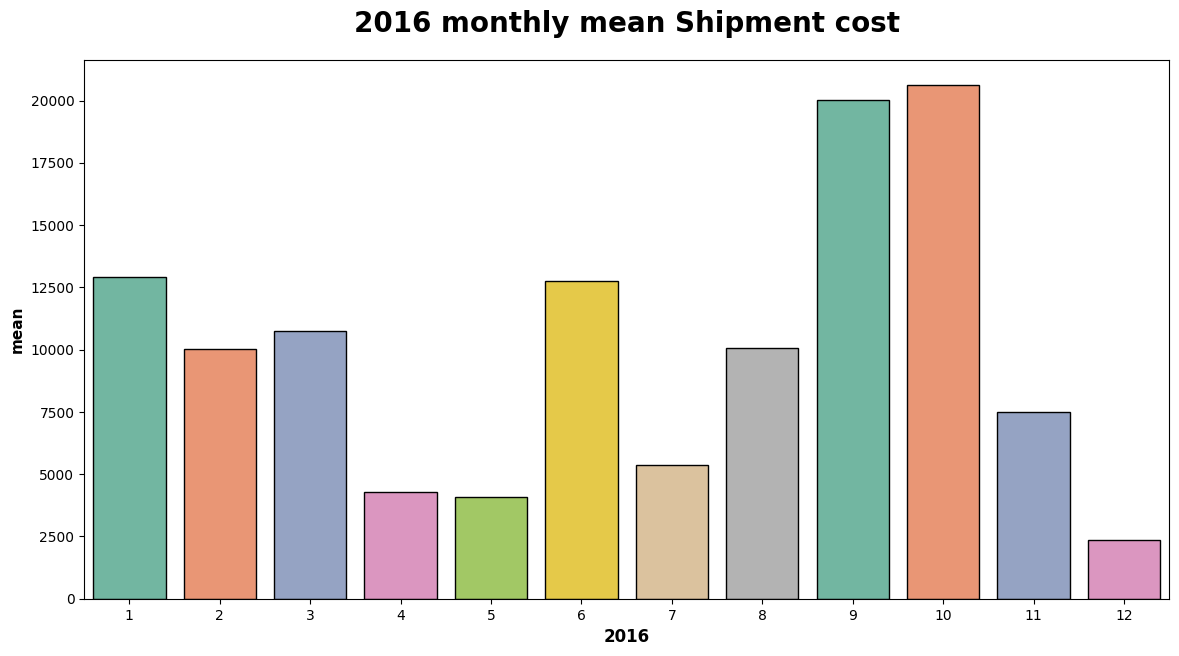

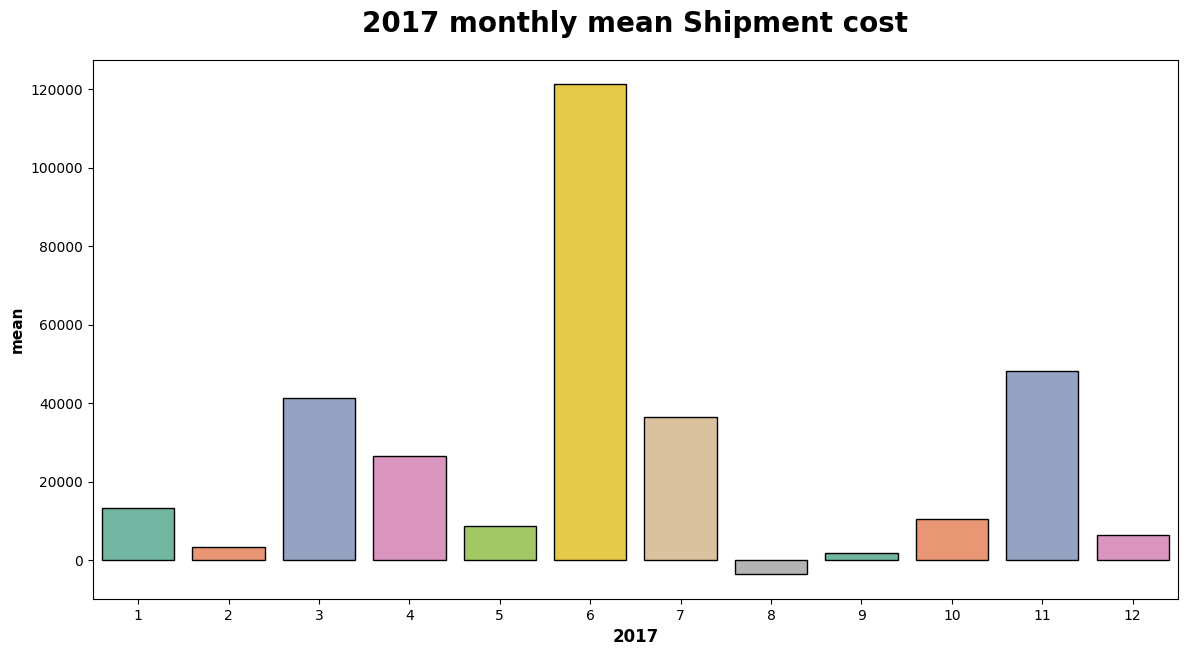

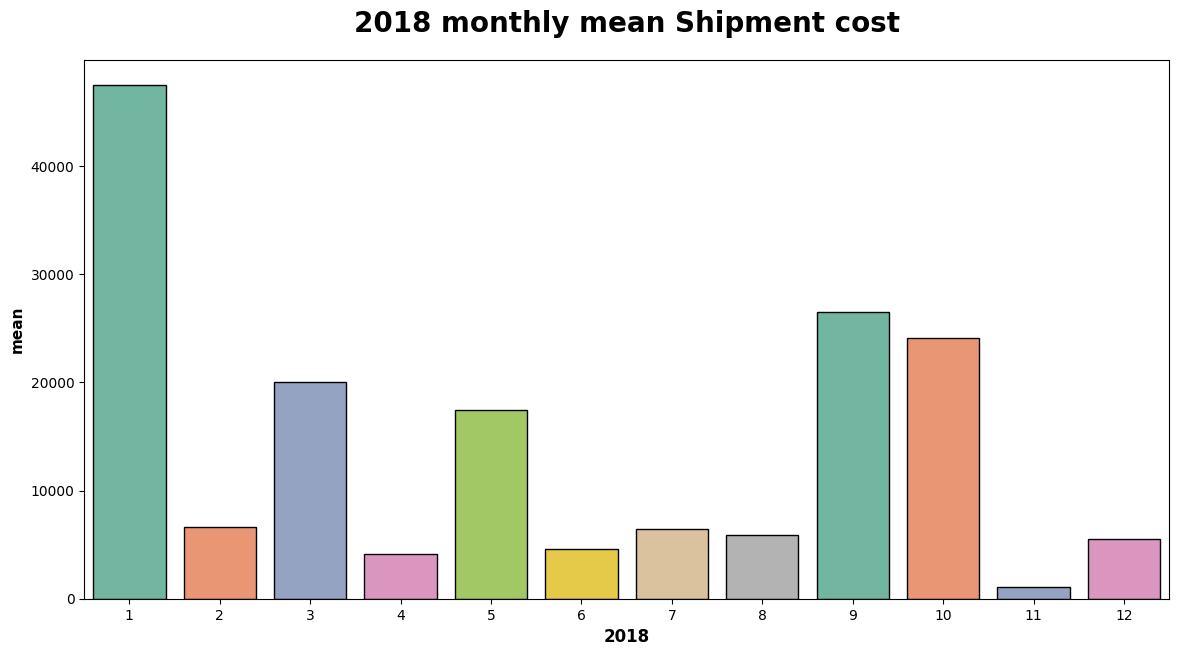

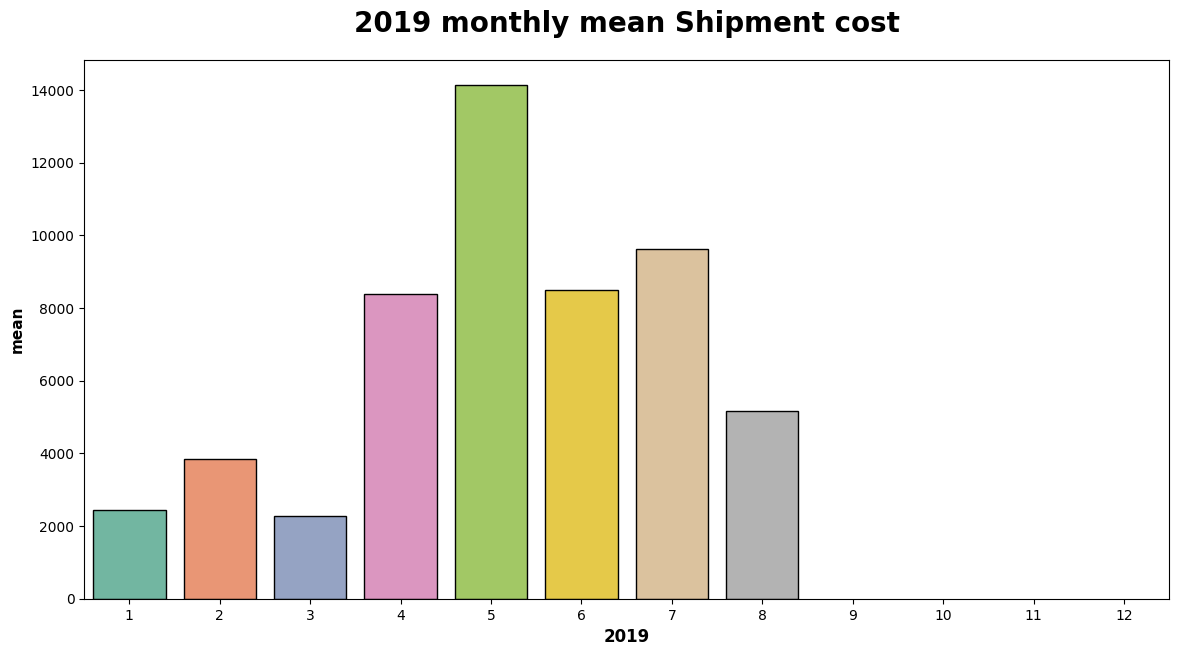

In [80]:
#  Monthly Cost Bar Charts Per Year

for i in df_wide.columns:
    plt.subplots(figsize=(14,7))
    sns.barplot(y=df_wide[i],x=df_wide.index,ec = "black", palette="Set2")
    plt.title(str(i) + " monthly mean Shipment cost", weight="bold",fontsize=20, pad=20)
    plt.ylabel("mean", weight="bold", fontsize=11)
    plt.xlabel(i, weight="bold", fontsize=12)
    plt.show()

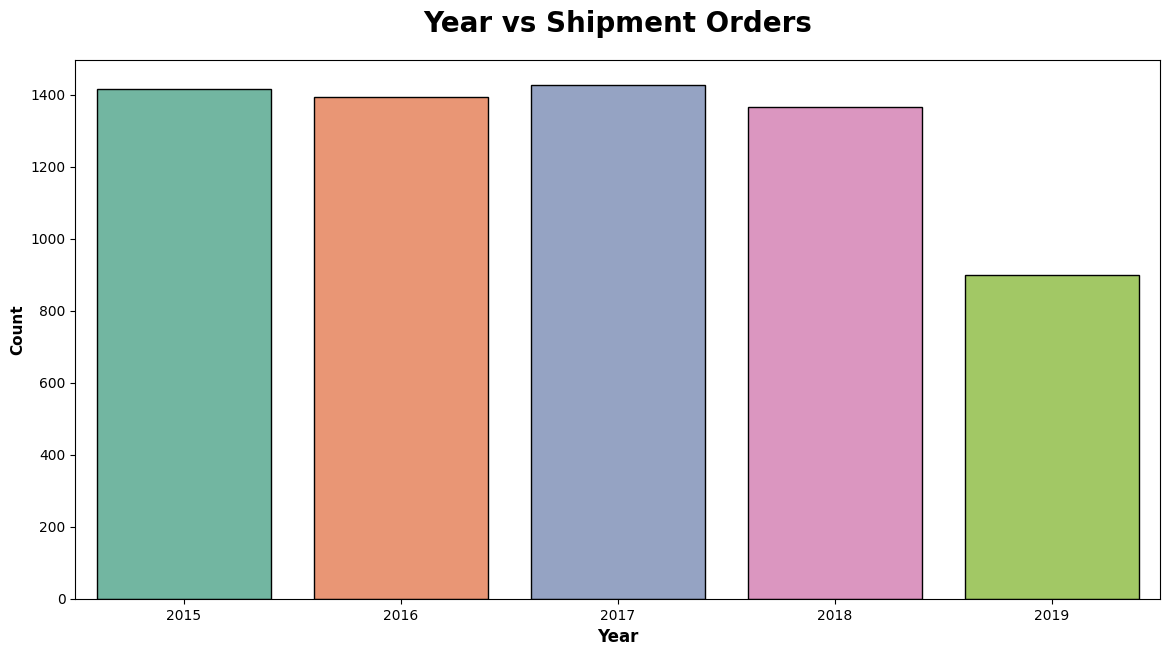

In [82]:
#order per year as graph
plt.subplots(figsize=(14,7))
sns.countplot(x=df.year,ec = "black", palette="Set2")
plt.title("Year vs Shipment Orders", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=11)
plt.xlabel("Year", weight="bold", fontsize=12)
plt.show()

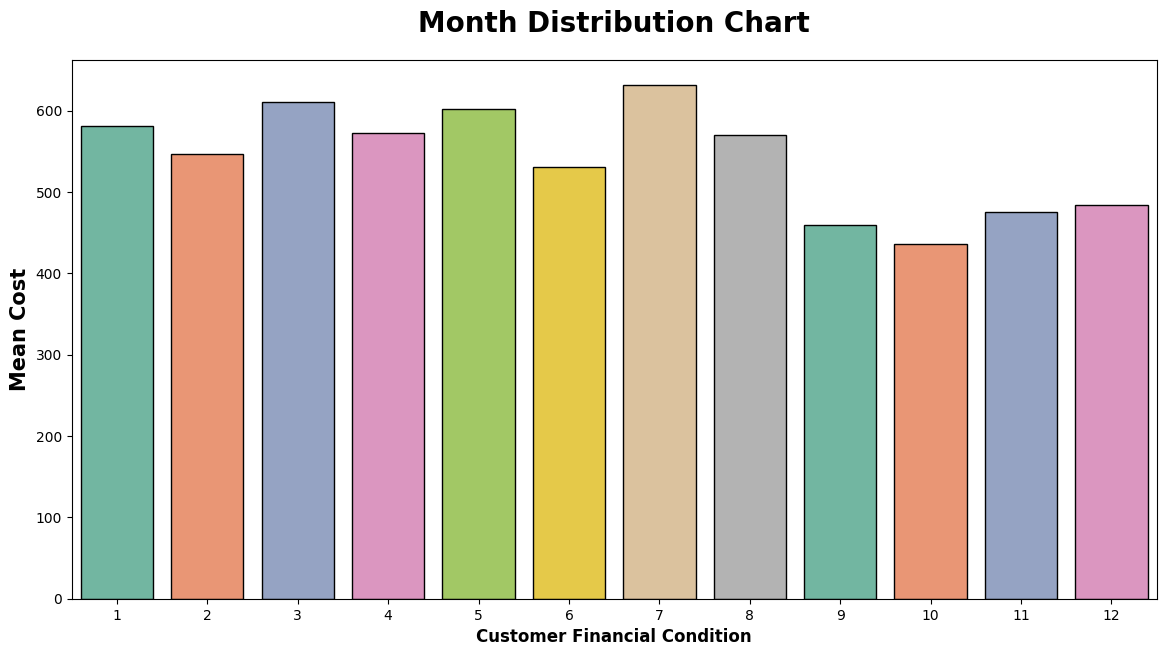

In [84]:
#Orders Per Month

plt.subplots(figsize=(14,7))
sns.countplot(x=df.month,ec = "black", palette="Set2")
plt.title("Month Distribution Chart", weight="bold",fontsize=20, pad=20)
plt.ylabel("Mean Cost", weight="bold", fontsize=15)
plt.xlabel("Customer Financial Condition", weight="bold", fontsize=12)
plt.show()